# Phase 3 Experiments: ABM and Stress Testing
This notebook runs four experiments:
- Uncontrolled baselines
- Policy effectiveness
- Mean-field limit breakdown
- Emergence and phase transitions

In [56]:
from pathlib import Path
import json
import argparse
import sys
import importlib
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import scripts.run_abm_experiments as rae
importlib.reload(rae)
run_all_experiments = rae.run_all_experiments

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


In [53]:
if device == 'cuda':
    torch.cuda.empty_cache()

mc_paths = 128 if device == 'cuda' else 400

args = argparse.Namespace(
    checkpoint='results/checkpoints/systemic_risk_alg1_bins_case_1_seed7.pt',
    output_dir='results/abm',
    case='case_1',
    device=device,
    state_dim=1,
    steps=20,
    horizon=0.2,
    sigma=1.0,
    default_threshold=-0.5,
    target_cascade_rate=0.35,
    q_min=0.1,
    q_max=1.4,
    q_steps=14,
    agents=100,
    core_hubs=10,
    er_p=0.08,
    mc_paths=mc_paths,
    seed=7,
    n_grid='10,30,100,300,1000',
    q_grid='0.4,0.6,0.8,1.0,1.2',
    phase_q_min=0.0,
    phase_q_max=3.0,
    phase_q_steps=25,
    phase_sigma=0.1,
    phase_threshold=0.0,
    phase_initial_mean=0.5,
    phase_horizon=1.0,
    phase_steps=100,
    phase_stress_fraction=0.1,
    phase_stress_value=-5.0,
)

try:
    out = run_all_experiments(args)
except torch.OutOfMemoryError:
    if device == 'cuda':
        torch.cuda.empty_cache()
    args.device = 'cpu'
    args.mc_paths = 200
    out = run_all_experiments(args)

Path(ROOT / args.output_dir).mkdir(parents=True, exist_ok=True)
out_path = ROOT / args.output_dir / 'abm_experiments_notebook.json'
out_path.write_text(json.dumps(out, indent=2), encoding='utf-8')
print('Saved:', out_path)
print('Calibrated q:', out['calibration']['selected_q'])
print('device used:', args.device)
print('mc_paths:', args.mc_paths)

Saved: C:\Users\adoni\Desktop\Interactions\project\results\abm\abm_experiments_notebook.json
Calibrated q: 0.10000000149011612
device used: cuda
mc_paths: 128


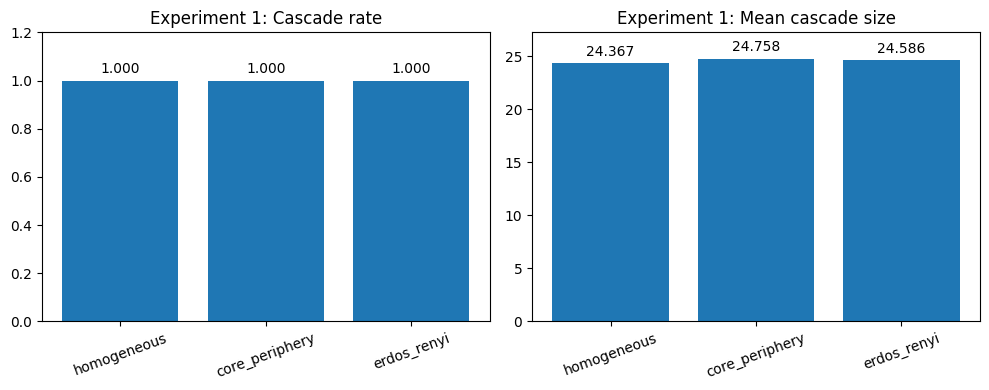

In [31]:
exp1 = out['experiment_1_uncontrolled']
names = ['homogeneous', 'core_periphery', 'erdos_renyi']
rates = [exp1[n]['stats']['cascade_rate'] for n in names]
sizes = [exp1[n]['stats']['mean_cascade_size'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bar_container = axes[0].bar(names, rates)
axes[0].bar_label(bar_container, fmt='%.3f', padding=3)
axes[0].set_title('Experiment 1: Cascade rate')
axes[0].set_ylim(0, 1.2)
axes[0].tick_params(axis='x', rotation=20)

bar_container = axes[1].bar(names, sizes)
axes[1].bar_label(bar_container, fmt='%.3f', padding=3)
axes[1].set_title('Experiment 1: Mean cascade size')
axes[1].set_ylim(0, max(sizes)*1.1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

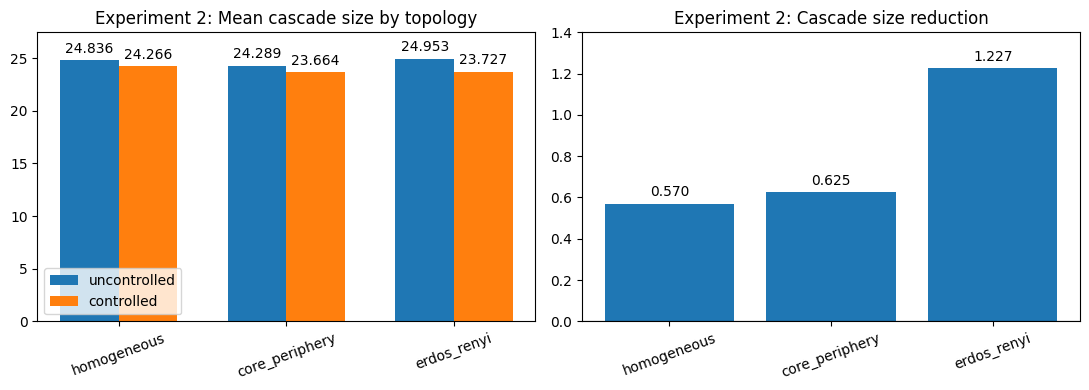

uncontrolled rates: [1.0, 1.0, 1.0]
controlled rates: [1.0, 1.0, 1.0]
rate reduction: [0.0, 0.0, 0.0]
size reduction: [0.5703125, 0.625, 1.2265625]
Mismatch vs homogeneous: {'core_periphery': {'rate': 0.0, 'size': -0.0546875}, 'erdos_renyi': {'rate': 0.0, 'size': -0.65625}}


In [41]:
exp2 = out['experiment_2_controlled']
uncontrolled_rates = [exp2[n]['uncontrolled']['stats']['cascade_rate'] for n in names]
controlled_rates = [exp2[n]['controlled']['stats']['cascade_rate'] for n in names]
uncontrolled_sizes = [exp2[n]['uncontrolled']['stats']['mean_cascade_size'] for n in names]
controlled_sizes = [exp2[n]['controlled']['stats']['mean_cascade_size'] for n in names]
reductions = [exp2[n]['cascade_reduction'] for n in names]
size_reductions = [exp2[n]['cascade_size_reduction'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
width = 0.35
x = list(range(len(names)))

bar_container1 = axes[0].bar([i - width / 2 for i in x], uncontrolled_sizes, width=width, label='uncontrolled')
bar_container2 = axes[0].bar([i + width / 2 for i in x], controlled_sizes, width=width, label='controlled')
axes[0].bar_label(bar_container1, fmt='%.3f', padding=3)
axes[0].bar_label(bar_container2, fmt='%.3f', padding=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20)
axes[0].set_ylim(0, max(uncontrolled_sizes + controlled_sizes)*1.1)
axes[0].set_title('Experiment 2: Mean cascade size by topology')
axes[0].legend()

bar_container = axes[1].bar(names, size_reductions)
axes[1].bar_label(bar_container, fmt='%.3f', padding=3)
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].set_title('Experiment 2: Cascade size reduction')
axes[1].set_ylim(0, 1.4)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('uncontrolled rates:', uncontrolled_rates)
print('controlled rates:', controlled_rates)
print('rate reduction:', reductions)
print('size reduction:', size_reductions)
print('Mismatch vs homogeneous:', exp2['mismatch_vs_homogeneous'])

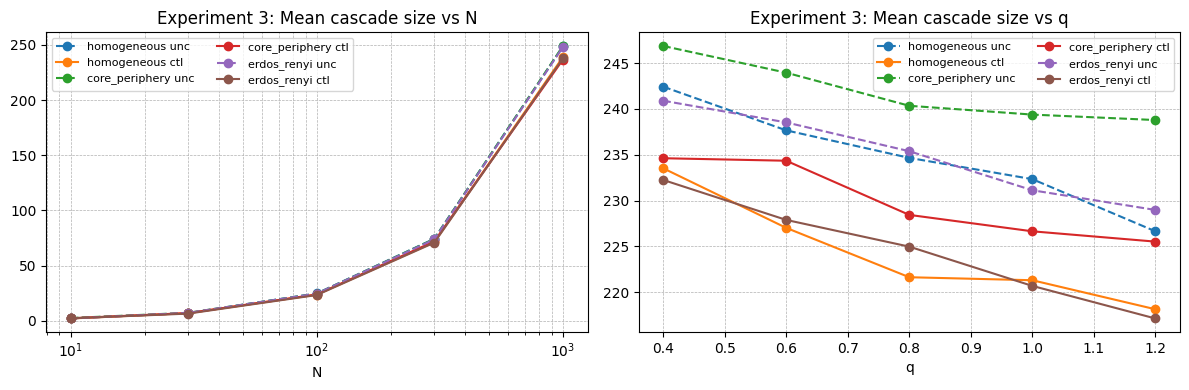

N-grid controlled sizes (homogeneous): [2.109375, 6.90625, 23.7265625, 71.21875, 238.9296875]
q-grid controlled sizes (homogeneous): [233.5234375, 227.0234375, 221.640625, 221.3125, 218.1484375]


In [38]:
exp3 = out['experiment_3_limit_breakdown']
vs_n = exp3['vs_N']
n_values = [item['N'] for item in vs_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in names:
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_n]
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_n]
    axes[0].plot(n_values, u_series, marker='o', linestyle='--', label=f'{name} unc')
    axes[0].plot(n_values, c_series, marker='o', label=f'{name} ctl')
axes[0].set_xscale('log')
axes[0].set_title('Experiment 3: Mean cascade size vs N')
axes[0].set_xlabel('N')
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

vs_q = exp3['vs_q']
q_values = [item['q'] for item in vs_q]
for name in names:
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_q]
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_q]
    axes[1].plot(q_values, u_series, marker='o', linestyle='--', label=f'{name} unc')
    axes[1].plot(q_values, c_series, marker='o', label=f'{name} ctl')
axes[1].set_title('Experiment 3: Mean cascade size vs q')
axes[1].set_xlabel('q')
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print('N-grid controlled sizes (homogeneous):', [item['topologies']['homogeneous']['controlled_mean_cascade_size'] for item in vs_n])
print('q-grid controlled sizes (homogeneous):', [item['topologies']['homogeneous']['controlled_mean_cascade_size'] for item in vs_q])

## Experiment 4: Emergence and phase transition

We sweep $q$ from subcritical to supercritical on the **uncontrolled** homogeneous ABM (no hub shock) and measure how the cascade rate and mean cascade size respond.

Near the critical $q^*$ the system exhibits a collective phase transition: a macroscopic fraction of agents defaults even though each individual coupling is weak. This is an instance of **interacting particle system (IPS) emergence** studied in the course.

The three sub-experiments are:

1. **Cascade rate and mean size vs $q$** — identify $q^*$ as the inflection point.
2. **Heavy-tail check near $q^*$** — a log-log plot of the cascade-size distribution; a power-law tail signals proximity to criticality.
3. **Policy-induced critical-point shift** — the MFC policy effectively shifts the phase boundary to a higher $q^*$, quantifying the policy's suppression power as a function of coupling strength.

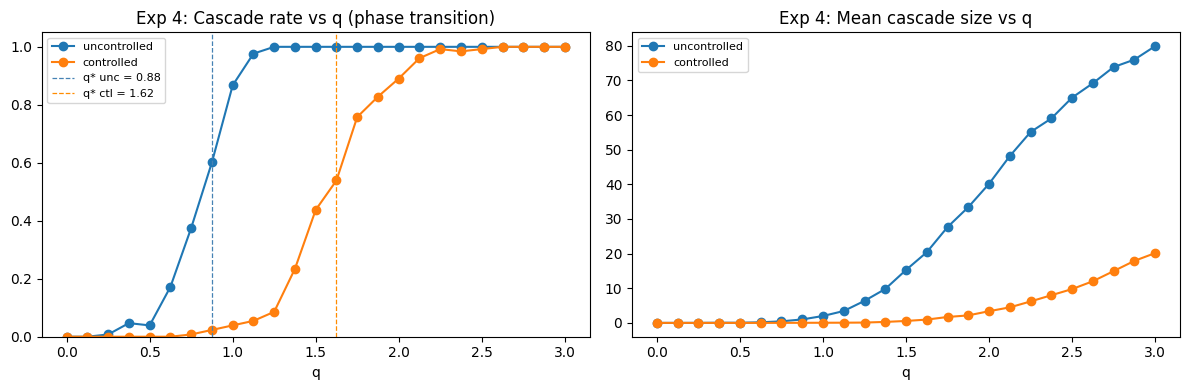

Critical q (uncontrolled): 0.875
Critical q (controlled):   1.625


In [ ]:
exp4 = out['experiment_4_phase_transition']
unc4 = exp4['uncontrolled']
ctl4 = exp4['controlled']
q4 = [row['q'] for row in unc4]
cq_unc = exp4['critical_q_uncontrolled']
cq_ctl = exp4['critical_q_controlled']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(q4, [row['cascade_rate'] for row in unc4], marker='o', label='uncontrolled')
axes[0].plot(q4, [row['cascade_rate'] for row in ctl4], marker='o', label='controlled')
if cq_unc is not None:
    axes[0].axvline(cq_unc, color='steelblue', ls='--', lw=0.9, label=f'q* unc = {cq_unc:.2f}')
if cq_ctl is not None:
    axes[0].axvline(cq_ctl, color='darkorange', ls='--', lw=0.9, label=f'q* ctl = {cq_ctl:.2f}')
axes[0].set_xlabel('q')
axes[0].set_ylabel('Cascade rate')
axes[0].set_title('Exp 4: Cascade rate vs q (phase transition)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

axes[1].plot(q4, [row['mean_cascade_size'] for row in unc4], marker='o', label='uncontrolled')
axes[1].plot(q4, [row['mean_cascade_size'] for row in ctl4], marker='o', label='controlled')
axes[1].set_xlabel('q')
axes[1].set_ylabel('Mean cascade size')
axes[1].set_title('Exp 4: Mean cascade size vs q')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Critical q (uncontrolled): {cq_unc}")
print(f"Critical q (controlled):   {cq_ctl}")

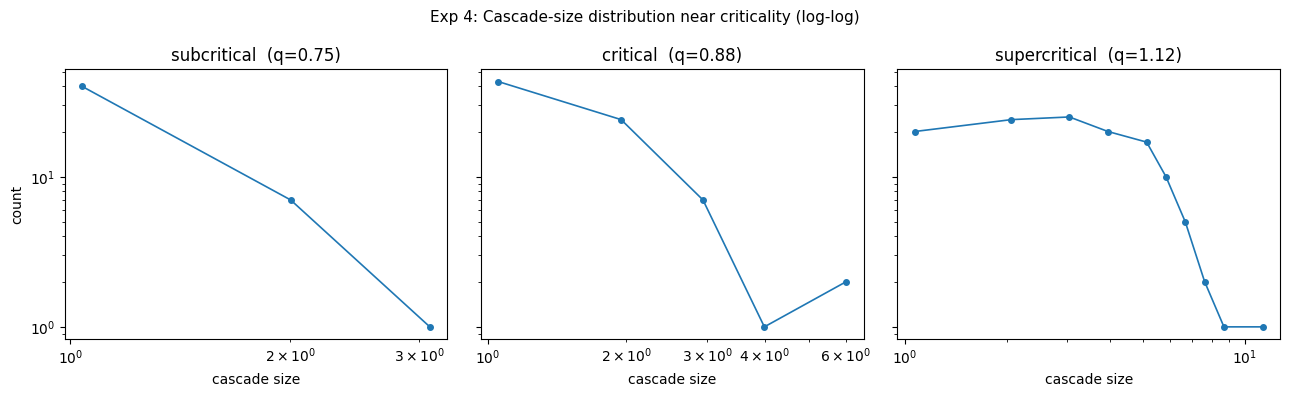

In [55]:
import numpy as np

crit_q = exp4['critical_q_uncontrolled']
q4_arr = [row['q'] for row in unc4]
below_idx = max((i for i, q in enumerate(q4_arr) if q < (crit_q or 0)), default=0)
at_idx = min(range(len(q4_arr)), key=lambda i: abs(q4_arr[i] - (crit_q or q4_arr[len(q4_arr)//2])))
above_idx = min(at_idx + 2, len(q4_arr) - 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, idx, label in zip(axes, [below_idx, at_idx, above_idx], ['subcritical', 'critical', 'supercritical']):
    sizes = [s for s in unc4[idx]['cascade_size_distribution'] if s > 0]
    if sizes:
        bins = np.logspace(np.log10(max(min(sizes), 1e-1)), np.log10(max(sizes) + 1), 20)
        counts, edges = np.histogram(sizes, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        mask = counts > 0
        ax.loglog(centers[mask], counts[mask], marker='o', markersize=4, lw=1.2)
    ax.set_title(f'{label}  (q={q4_arr[idx]:.2f})')
    ax.set_xlabel('cascade size')
axes[0].set_ylabel('count')
fig.suptitle('Exp 4: Cascade-size distribution near criticality (log-log)', fontsize=11)
plt.tight_layout()
plt.show()